# Title: 2020 U.S. Election
#### Student ID:
##### Abby Arroyo: 2670127
##### Angie Chen:
##### Michelle Do:
##### Susanna Wang: 

## Introduction:
##### intro (fill out)

## Data Description:

One of the datasets we will be using is president_county_candidate. It has 32177 rows and 6 columns. It contains every state and their counties. It shows each county's number of votes for each presidential candidate and who won for each county. The party of each candidate is also listed. Each row is relevant and shows: a state, a county, a presidential candidate, the party of the presidential candidate, the number of votes for that presidential candidate, and if that candidate won in the county.

The "governors_county_candidate" dataset shows state governor election results at the county-level. Each row, or observation, represents a candidate's results in a particular county. The variables include the state and county in which the cnadidate ran, candidate name, their affiliated political party, total votes the candidate received in that county, and whether they won in that specific county.

Each observation in the "house_candidate" describes voting results for a candidates in a particular district. Unlike the previous datasets, a state can elect more than one house representative. Winning in one district meant representing the state in the house. Additionally, the data is collected at the district-level, so I must clean it by adding a "State" column to group the districts into appropriate states.

##### description about the dataset tables: president_county_candidate.csv, house_candidate.csv, governors_county_candidate.csv, senate_county_candidate.csv *talk about revalant rows, # of obervations, and brief overview(fill out)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pres = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
house = pd.read_csv("4-US_Election_2020/house_candidate.csv")
sen = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")
gov = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")

In [2]:
print(f"president_county_candidate number of rows and columns, repectively: {pres.shape}")
print()
print(f"governor_county_candidate number of rows and columns, respectively: {gov.shape}")
print()
print(f"house_candidate number of rows and columns, respectively: {house.shape}")

president_county_candidate number of rows and columns, repectively: (32177, 6)

governor_county_candidate number of rows and columns, respectively: (5145, 6)

house_candidate number of rows and columns, respectively: (1215, 5)


##### description 1 paragraph about data cleaning (fill out)
The presidential data is cleaned so it shows the proportion of Democratic, Republican, and Independent votes for each state and the party of the president the state voted for. All parties that are not Democrat or Republican are recoded to Independent. 

The "house_candidate" dataset, only describes the district making it difficult to extract information at the state-level for each winning candidate. I have to sort the districts into appropriate U.S. states and appended the resulting list as a new column labeled "States". Also, I must consider the extraneous "Oth district" that doesn't actually belong to any state. Because there are a different number of representatives for each state, I recode for HOUSE MAJORITY, or the political party that a majority of the winners align with. 

In [3]:

#The data table produced by this code shows the proportion of Democrat, Republican, and Independent votes for each state and the party of the president the state voted for.
# Code for cleaning the presidential data so it shows Democratic, Republican, and Independent party proportions
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []

for group in pres.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
pres_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner}).round(3)
display(pres_proportions.head())

###########################################################################################################################################################################################

# Code for cleaning the house_candidate data so it shows votor data for each state in the house and excludes the extraneous district

states_list = [ #keyword list to that Boolean in FOR loop below selects from
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "West Virginia", "Washington", "Virginia", "Wisconsin", "Wyoming"
]
States = []

for district in house["district"]: #for every obs. in "district" column
    for index in range(len(states_list)): # go through every keyword in states_list
        if states_list[index] in district: # Is the state is listed in the district name
            States.append(states_list[index]) 
            break #do not need to check for the state after
    else:
        States.append("None") #consider the "United State's 0th district" = None

house["States"] = States #append newly assigned states list as new variable column

placeholder_winner = house.query("(district == 'United States’s 0th district') and (won == True)").index #Find the extra district not belonging to any state
house.iloc[placeholder_winner, -2] = False # set "won" = False to make exclude this district from the agg. winner's list later on 

###########################################################################################################################################################################################

# Code for recoding the house_candidate data so it shows democratic, republican, and independent party proportions for each state
house_winners_agg = house.query("won == True") #we are only interestedi

states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []
total_reps = []

for group in house_winners_agg.groupby("States"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for party in state_data["party"]: #loops through "total_votes" and "party" for each state
        total = total + 1 #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + 1
        elif party == "REP":
            rep = rep + 1
        else:
            ind = ind + 1
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)  
    total_reps.append(total)

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    elif prop_dems == prop_reps:
        win = "TIE"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
house_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind,"Total_Reps": total_reps, "House_Majority": winner})



# Code for cleaning the governors data so it shows Democratic, Republican, and Independent party proportions
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []

for group in gov.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
governor_proportions = pd.DataFrame({"State": states, "Governor_Party": winner})



# Code for cleaning the senate data so it shows democratic, republican, and independent party proportions for each state
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []

for group in sen.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
sen_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner})

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner
0,Alabama,0.366,0.620,0.014,REP
1,Alaska,0.392,0.485,0.123,REP
2,Arizona,0.494,0.491,0.016,DEM
3,Arkansas,0.348,0.624,0.028,REP
4,California,0.635,0.343,0.022,DEM


##### description about merging procedure (fill out)
Merge dataframe of overall presidential party, party of elected senator, party of elected governor, and majority party of elected house representatives for each state.  

In [4]:
# code for merging angie and michelle's portion (fill out)


state_senator = pd.merge(left = pres_proportions[["State","Winner"]], #merge elected senator party df with elected presidential party df
    right = sen_proportions[["State", "Winner"]], 
    how = "left", on = "State")
state_senator = state_senator.rename(columns = {"Winner_y": "Senator_Party", #change column names
                                                "Winner_x": "Winner"})

state_senator_house = pd.merge(left = state_senator, #add house majority party df with merged one from above
    right = house_proportions[["State", "House_Majority"]], 
    how = "left", on = "State")

merged = pd.merge(left = state_senator_house, # final merge by adding governor political party df 
    right = governor_proportions[["State", "Governor_Party"]], 
    how = "left", on = "State")

display(merged)

,State,Winner,Senator_Party,House_Majority,Governor_Party
0,Alabama,REP,DEM,REP,NaN
1,Alaska,REP,DEM,REP,NaN
2,Arizona,DEM,REP,DEM,NaN
3,Arkansas,REP,IND,REP,NaN
4,California,DEM,NaN,DEM,NaN
5,Colorado,DEM,REP,DEM,NaN
6,Connecticut,DEM,NaN,DEM,NaN
7,Delaware,DEM,REP,DEM,DEM
8,District of Columbia,DEM,NaN,NaN,NaN
9,Florida,REP,NaN,REP,NaN


##### description 1 paragraph about the main columns after cleaning (fill out) - angie does this

## Results:

#### Subquestion 1: Are states that vote Democrat or Republican for president more likely to vote for Independent candidates?

The data table below shows the average proportion of independent votes for states that vote democrat or republican for president.

Winner
DEM    0.021
REP    0.026
Name: Proportion_Independent, dtype: float64

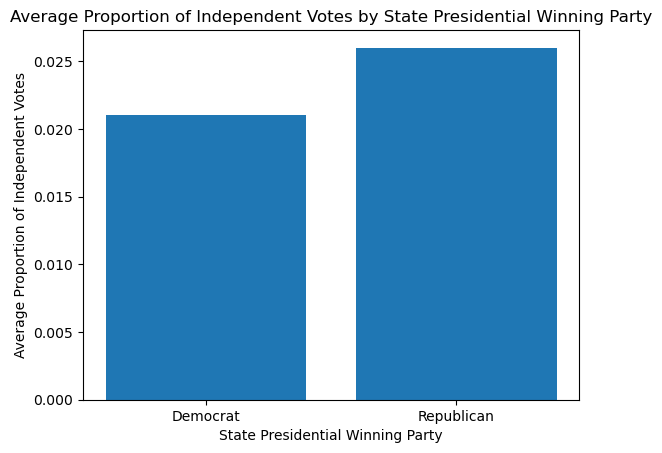

In [5]:
# Abby's code and graph

#groups pres_proportions by "Winner" which is the party the state voted for president.
#Proportion_Independent"].mean() takes the mean of the proportion of independent votes for democratic and republican states
ind_prop_party = pres_proportions.groupby(by = "Winner")["Proportion_Independent"].mean().round(3)
display(ind_prop_party)

party = ["Democrat", "Republican"]
count = [ind_prop_party.iloc[0],ind_prop_party.iloc[1]] #Grabs the proportion of indpendent votes for democrats and republicans respectively
plt.bar(x=party, height=count)
plt.xlabel("State Presidential Winning Party")
plt.ylabel("Average Proportion of Independent Votes")
plt.title("Average Proportion of Independent Votes by State Presidential Winning Party")
plt.show()

We found that there was a greater average proportion of independent votes in states that voted republican for president by about 5%. We would need to do further analysis to see if there was a statistically significant difference between the two.

#### Subquestion 2: Are states with a greater mix of Republicans and Democrats more likely to have more votes for an independent candidate?

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner,Dem-Rep
0,Alabama,0.366,0.620,0.014,REP,-0.254
1,Alaska,0.392,0.485,0.123,REP,-0.093
2,Arizona,0.494,0.491,0.016,DEM,0.003
3,Arkansas,0.348,0.624,0.028,REP,-0.276
4,California,0.635,0.343,0.022,DEM,0.292
5,Colorado,0.554,0.419,0.027,DEM,0.135
6,Connecticut,0.592,0.392,0.016,DEM,0.200
7,Delaware,0.588,0.398,0.014,DEM,0.190
8,District of Columbia,0.921,0.054,0.025,DEM,0.867
9,Florida,0.479,0.512,0.009,REP,-0.033


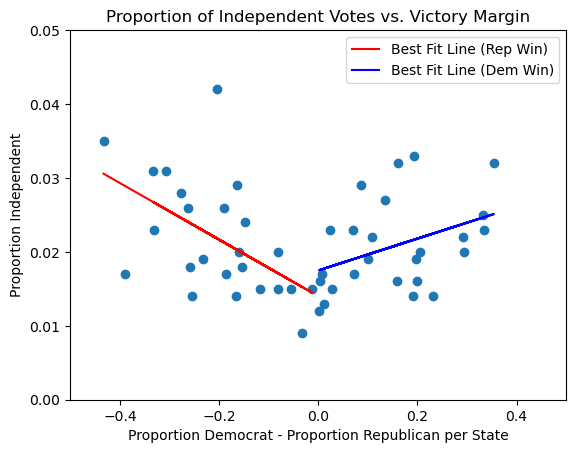

In [6]:
# Susanna's code and graph

#this creates a new column that shows the winning margin for each state by subtracting the proportion of republican votes from the proportion of democratic votes. A positive value shows that Democrats won and a negative value shows that republicans won.
pres_proportions["Dem-Rep"] = pres_proportions["Proportion_Democrat"] - pres_proportions["Proportion_Republican"]
display(pres_proportions)

#this creates new x and y values without the outliers
no_out_x = pres_proportions["Dem-Rep"].loc[(pres_proportions["Dem-Rep"] < 0.5) & (pres_proportions["Dem-Rep"] > -0.5) & (pres_proportions["Proportion_Independent"] < 0.06)]
no_out_y = pres_proportions["Proportion_Independent"].loc[(pres_proportions["Dem-Rep"] < 0.5) & (pres_proportions["Dem-Rep"] > -0.5) & (pres_proportions["Proportion_Independent"] < 0.06)]

plt.scatter(no_out_x, no_out_y)
plt.xlim(-0.5, 0.5) 
plt.ylim(0, 0.05)
plt.xlabel("Proportion Democrat - Proportion Republican per State")
plt.ylabel("Proportion Independent")
plt.title("Proportion of Independent Votes vs. Victory Margin")

#this creates the first line that shows the line of best fit for the margins where republicans won (negative margin)
first_pres = no_out_x.loc[pres_proportions["Dem-Rep"] < 0]
first_ind = no_out_y.loc[pres_proportions["Dem-Rep"] < 0]
coefficients = np.polyfit(first_pres, first_ind, 1)
slope, intercept = coefficients
best_fit_line = slope * first_pres + intercept
plt.plot(first_pres, best_fit_line, color='red', label='Best Fit Line (Rep Win)')


#this creates the second line that shows the line of best fit for the margins where democrats won (positive margin)
sec_pres = no_out_x.loc[pres_proportions["Dem-Rep"] > 0]
sec_ind = no_out_y.loc[pres_proportions["Dem-Rep"] > 0]
coefficients = np.polyfit(sec_pres, sec_ind, 1)
slope, intercept = coefficients
best_fit_line = slope * sec_pres + intercept
plt.plot(sec_pres, best_fit_line, color='blue', label='Best Fit Line (Dem Win)')

plt.legend()
plt.show()

##### Findings
This graph shows the relationship between the margin of winning to the proportion of independent votes per state. The graph shows that as the margin of winning becomes greater, the proportion of independent votes increases. The graph also shows that there is a greater proportion of independent votes when Republicans win, compared to when Democrats win. 

#### Subquestion 3: How often does a state’s presidential party vote match the senator, house rep and governor party?


I query variables from the the merged dataframe to identify frequency of states that have the same political party across their overall presidential, senate, house, and governor elections. To organize the data, I sorted all information into a table.

The senate and governor datasets only included 34 and 11 participating states, respectively. Raw counts alone may be misleading, so I also calculated proportions. For example, among the 34 states that did elect new senators or the 11 states that did elect new governors, repectively, what proportion of these align with the overall state presidential party? 

,Comparisons,Number_of_States,Proportion,Relevant_States
0,President vs Senate,4,0.12,"[Maine, Michigan, North Carolina, Texas]"
1,President vs House Majority,45,0.88,"[Alabama, Alaska, Arizona, Arkansas, Californi..."
2,President vs Governor,8,0.73,"[Delaware, Indiana, Missouri, Montana, North D..."
3,President vs Senate & House,3,0.06,"[Maine, North Carolina, Texas]"
4,"President vs Senate, House & Governor",0,0.00,N/A


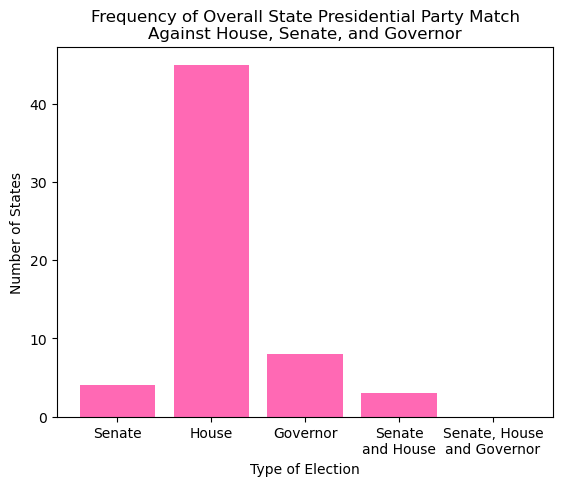

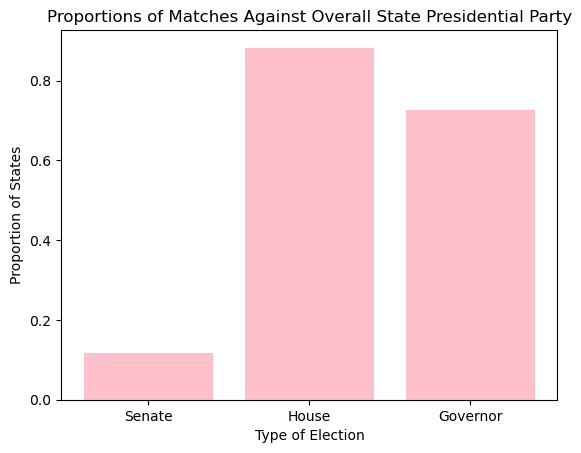

In [7]:


labels = [ #column with descriptions for which type of election we're comparing political parties to 
    "President vs Senate",
    "President vs House Majority",
    "President vs Governor",
    "President vs Senate & House",
    "President vs Senate, House & Governor"
    ]

raw_counts = [ #number of states that have the same political party between presidential and respective election listed below
    len(merged.query("Winner == Senator_Party")), #compute number of obs. that have same string (party) under "Winner" col and "Senator_Party" col
    len(merged.query("Winner == House_Majority")),
    len(merged.query("(Winner == Governor_Party)")), 
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party)")), 
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party) and (Winner==Governor_Party)"))
    ]

proportions = [ #proportions of number of political party matches among states that actually participated in different elections
    len(merged.query("Winner == Senator_Party"))/len(sen["state"].unique()),  # number of presidential & senate matches / 34 states that actually held senator elections
    len(merged.query("Winner == House_Majority"))/len(house["States"].unique()), #denominator computes number of unique strings under "state" column
    len(merged.query("(Winner == Governor_Party)"))/len(gov["state"].unique()), # number of presidential & governor matches / 11 states that actually held senator elections
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party)"))/len(pres["state"].unique()), # number of presidential & senate & house matches / all states
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party) and (Winner==Governor_Party)"))/len(pres["state"].unique())
]

relevant_states = [#list all states that have the political party matches
    merged.query("Winner == Senator_Party")["State"].tolist(), #grab the specific states with matching political parties between president and senator
    merged.query("Winner == House_Majority")["State"].tolist(), #.tolist converts series to list; better formatting
    merged.query("(Winner == Governor_Party)")["State"].tolist(),
    merged.query("(Winner == House_Majority) and (Winner==Senator_Party)")["State"].tolist(),
    "N/A"
]
match_table = pd.DataFrame({"Comparisons": labels , "Number_of_States" : raw_counts, "Proportion" : proportions, "Relevant_States" : relevant_states})
display(round(match_table,2)) #create and round dataframe

###########################################################################################################################################################################################

# Bar plots created from information in table 
# Raw counts of number of matches 
categories = ["Senate", "House", "Governor", "Senate\nand House", "Senate, House\nand Governor"] #x-axis labels
num_states = raw_counts #number of states with political party matches taken from table above

plt.bar(x = categories, height = num_states, color = "hotpink") #create bar plot
plt.xlabel("Type of Election")
plt.ylabel("Number of States")
plt.title("Frequency of Overall State Presidential Party Match\nAgainst House, Senate, and Governor")
plt.show()

#Proportions of matches among states that participated for each elected position
categories = ["Senate", "House", "Governor"]
proportions_state = [    #taken from table above
    len(merged.query("Winner == Senator_Party"))/len(sen["state"].unique()),
    len(merged.query("Winner == House_Majority"))/len(house["States"].unique()),
    len(merged.query("(Winner == Governor_Party)"))/len(gov["state"].unique())]

plt.bar(x = categories, height = proportions_state, color = "pink")
plt.xlabel("Type of Election")
plt.ylabel("Proportion of States")
plt.title("Proportions of Matches Against Overall State Presidential Party")
plt.show()

##### Findings:
The first bar graph compares the raw count of states that have the same political party between their senate, house, and governor elections when compared to overall presidential elections.
The second bar graph provides the proportion of states that have the same political party as their overall presidential party, AMONG the ones that did particpate in elections for their respective groups in the x-axis. For instance, among the 34 states that elected new senators in the 2020 US Elections, ~12% had the same political group for their senator and president. 

For the most part, political parties were identical across presidential and house majority elections. A large proportion of states that did elect new governors for the 2020 cycle also had an identical political party to their presidential party. The frequency just appears lower due the limited governors elected. This information is consistent with what we'd expect in that states with a general political ideology will opt to elect leaders with identify in the same party. 
What stands out is the how many senators elected identified with political parties that were different than their state's presidential party. This could be due to other factors such as geography, economic standing, and education level of voters in the state. Future research could look into these variables and obtain a more detailed dataset. 

#### Subquestion 4: What percentage of the time do the chosen president, senator, house representative, and governor match in party for presidential swing states? 

In [8]:
# Angie's code and graph

pres_proportions["margin"] = pres_proportions["Proportion_Democrat"] - pres_proportions["Proportion_Republican"]
pres_proportions["margin_abs"] = abs(pres_proportions["margin"])
swing = pres_proportions.query("margin_abs <= 0.05")
swing

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner,Dem-Rep,margin,margin_abs
2,Arizona,0.494,0.491,0.016,DEM,0.003,0.003,0.003
9,Florida,0.479,0.512,0.009,REP,-0.033,-0.033,0.033
10,Georgia,0.495,0.493,0.012,DEM,0.002,0.002,0.002
22,Michigan,0.506,0.478,0.015,DEM,0.028,0.028,0.028
28,Nevada,0.501,0.477,0.023,DEM,0.024,0.024,0.024
33,North Carolina,0.486,0.499,0.015,REP,-0.013,-0.013,0.013
38,Pennsylvania,0.500,0.488,0.013,DEM,0.012,0.012,0.012
49,Wisconsin,0.495,0.488,0.017,DEM,0.007,0.007,0.007


##### Angie's explanation of the findings

#### Subquestion 5: What are the proportions of Democrats and Republicans in the senate and house compared to the winning margin of presidential swing states?

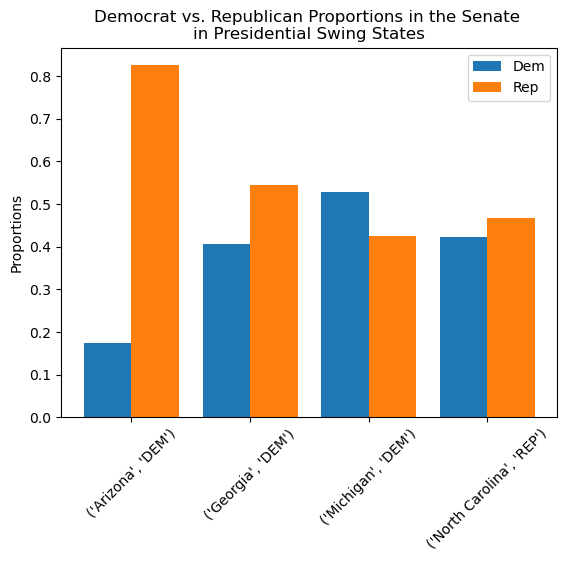

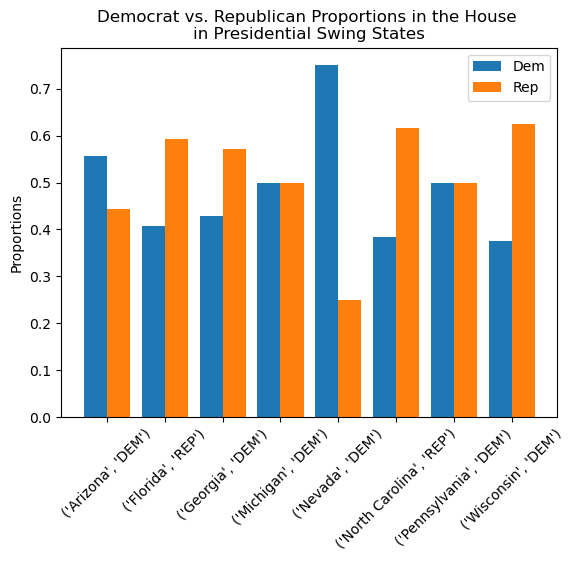

In [9]:
# Susanna's code and graph

cats = swing["State"].tolist() # created a list of states that are presidential swings

senate = sen_proportions.query("State in @cats") # took the senate proportions of states that are presidential swings
senate_list = senate["State"].tolist()

pres_swing = pres_proportions.query("State in @senate_list") # took the presidential proportions of states that are presidential swings    
presswing_list = pres_swing["Winner"].tolist()

paired = list(zip(senate_list, presswing_list))

v1, v2 = senate["Proportion_Democrat"], senate["Proportion_Republican"]
w, x = 0.4, np.arange(len(paired))

plt.bar(x - w/2, v1, w, label='Dem')
plt.bar(x + w/2, v2, w, label='Rep')

plt.xticks(x, paired, rotation=45)
plt.ylabel('Proportions')
plt.title('Democrat vs. Republican Proportions in the Senate \nin Presidential Swing States')
plt.legend()
plt.show()


house = house_proportions.query("State in @cats") # took the house proportions of states that are presidential swings
house_list = house["State"].tolist() # created a list of states that have house proportions of presidential swings

pres_swing_house = pres_proportions.query("State in @house_list") # took the presidential proportions of states that are presidential swings    
presswing_list_house = pres_swing_house["Winner"].tolist()

paired2 = list(zip(house_list, presswing_list_house))

v1, v2 = house["Proportion_Democrat"], house["Proportion_Republican"]
w, x = 0.4, np.arange(len(paired2))

plt.bar(x - w/2, v1, w, label='Dem')
plt.bar(x + w/2, v2, w, label='Rep')

plt.xticks(x, paired2, rotation=45)
plt.ylabel('Proportions')
plt.title('Democrat vs. Republican Proportions in the House \nin Presidential Swing States')
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Susanna's explanation of the findings

The first graph shows the distribution of the Senate votes by parties in the presidential swing with the x-axis label indicating which way the presidential election ended up going while the second graph shows the same distribution but with the House of Representative. There are only 4 state senate votes in the 2020 year that were also presidential swings, so the first graph only had 4 states. The data does not have a specific pattern, meaning that swing states' house and senate votes are not correlated to their swing state status or what party ended up winning the state in the presidential election. However, there is a slight trend of the house and senate going the party direction of the presidential election. 

#### Subquestion 6: Is there an association between the victory margin in the presidential election and the proportion of party votes in the Senate and House.

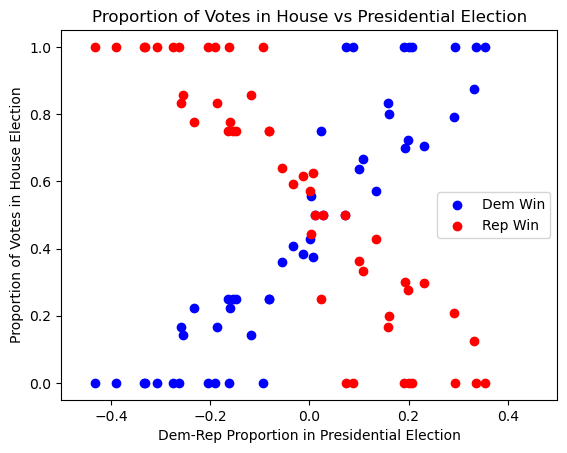

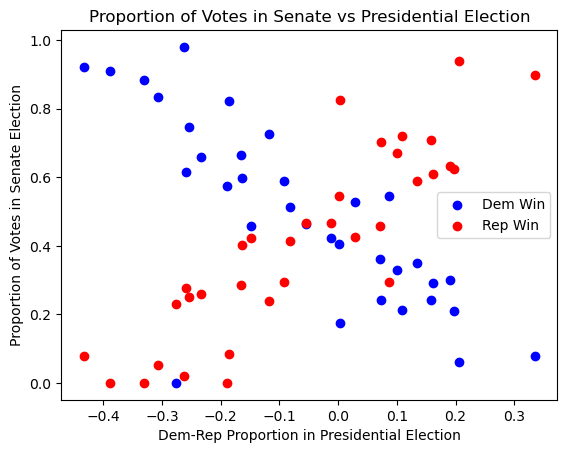

In [10]:
# Susanna's code and graph

pres_props = pres_proportions.query("State != 'District of Columbia'") #removed DC because it is not a state

plt.scatter(pres_props["Dem-Rep"], house_proportions["Proportion_Democrat"], label = "Dem Win", color = "blue")
plt.scatter(pres_props["Dem-Rep"], house_proportions["Proportion_Republican"], label = "Rep Win", color = "red")
plt.xlim(-0.5, 0.5)
plt.xlabel("Dem-Rep Proportion in Presidential Election")
plt.ylabel("Proportion of Votes in House Election")
plt.title("Proportion of Votes in House vs Presidential Election")
plt.legend()
plt.show()

senate_list = sen["state"].tolist() #created a list of states that have senate proportions
pres_props2 = pres_proportions.query("State in @senate_list") #created a list of states that are in the senate list and a swing state

plt.scatter(pres_props2["Dem-Rep"], sen_proportions["Proportion_Democrat"], label = "Dem Win", color = "blue")
plt.scatter(pres_props2["Dem-Rep"], sen_proportions["Proportion_Republican"], label = "Rep Win", color = "red")
plt.xlabel("Dem-Rep Proportion in Presidential Election")
plt.ylabel("Proportion of Votes in Senate Election")
plt.title("Proportion of Votes in Senate vs Presidential Election")
plt.legend()
plt.show()

##### Susanna's explanation of the findings

The first graph shows the association between the winning margin of the presidential election and the republican and democratic proportion distribution in the House of representative votes. The results show that when one party win the presidential election in a state, they usually win the house in that state too. This seems reasonable since if a state usually votes one party, they will usually vote the same party between the presidential and house elections.

The second graph shows the association between the winning margin of the presidential election and the republican and democratic proportion distribution in the Senate votes. These results are interesting since when one party win the presidential election in a state, the opposite party wins the senate votes in that state. A variety of factors can explain this including incumbency, votor turnout, local issues, and candidates, but further research is needed to find the exact reasoning.

## Discussion:
##### summarize findings and main things learned 1-2 paragraphs (fill out)